In [1]:
# Imports
import antares_devkit as dk
from antares_devkit.models import DevKitLocus

# Writing a preliminary microlensing filter that reads in the photometry

In [2]:
from antares_client import search

In [3]:
import numpy as np
from astropy.table import MaskedColumn
import warnings
import astropy
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import skew
from antares_devkit.models import BaseFilter
from bagle import model, model_fitter
from astropy.stats import sigma_clip
from scipy.stats import chi2
import math
from astropy.stats import sigma_clip
import antares_microlensing_filter
from importlib.metadata import version

- Forced photometry or DIA photometry longer?
- Change names to generic antares
- Rubin vs ZTF if statement
- ZTF filter capital R and lowercase g

In [25]:
class microlensing(BaseFilter):
    INPUT_LOCUS_PROPERTIES = [
        'ant_object_id',
    ]

    REQUIRED_TAGS = ['lc_feature_extractor']

    SLACK_CHANNEL = "#filter-microlensing"

    OUTPUT_TAGS = [
        {
            'name': 'microlensing_candidate',
            'description': 'Locus - a transient candidate - exhibits a microlensing-like variability',
        }
    ]

    np = None
    curve_fit = None
    skew = None
    sigma_clip = None

    # Define a Paczyński microlensing model
    def paczynski(self, t, t0, u0, tE, F_s):
        """
        Paczyński microlensing light curve model
        t0 : peak time
        u0 : impact parameter
        tE : Einstein crossing time
        F_s : source flux
        F_b : blended flux
        """
        u = self.np.sqrt(u0 ** 2 + ((t - t0) / tE) ** 2)
        A = (u ** 2 + 2) / (u * self.np.sqrt(u ** 2 + 4))
        return F_s * (A) + (1 - F_s)

    def fit_paczynski(self, times, mags, flxs, flx_errs):
        """
        Fit the Paczyński microlensing model to flux data.
        Returns best-fit parameters and chi-squared value.
        """
        if len(times) < 4:
            return None, None  # Not enough data

        # initial guesses
        t0_guess = times[self.np.argmin(flxs)]
        u0_guess = 1.0 / (self.np.max(flxs))

        tE_guess = 20.0
        F0_guess = 0.5

        initial_guess = [t0_guess, u0_guess, tE_guess, F0_guess]

        bounds = (
            [times.min() - 50, 0, 1.0, 0.0],
            [times.max() + 50, self.np.inf, 500.0, 1]
        )

        try:
            popt, _ = self.curve_fit(
                self.paczynski,
                times, flxs,
                p0=initial_guess,
                sigma=flx_errs,
                bounds=bounds,

                maxfev=5000
            )
            chi2 = self.np.sum(((flxs - self.paczynski(times, *popt)) / flx_errs) ** 2) / len(times)
            return popt, chi2
        except Exception as e:
            print(f"  Paczynski fitting error: {e}")
            return None, None

    def mag_to_flux(self, mag, F0=1.0):
        """
        Convert magnitude to flux.

        Parameters:
        - mag : magnitude (float or array)
        - F0 : reference flux (zeropoint), default=1.0 for relative flux

        Returns:
        - flux : flux corresponding to the magnitude
        """
        flux = F0 * 10 ** (-0.4 * mag)
        flux = flux / self.np.min(flux)
        return flux

    def magerr_to_fluxerr(self, mag, mag_err, F0=1.0):
        """
        Convert magnitude uncertainty to flux uncertainty.

        Parameters:
        - mag : magnitude value or array
        - mag_err : magnitude uncertainty value or array
        - F0 : zeropoint flux (default=1.0 for relative flux)

        Returns:
        - flux_err : flux uncertainty
        """
        flux = self.mag_to_flux(mag, F0)
        flux_err = 0.4 * self.np.log(10) * flux * mag_err
        return flux_err

    # Chi squared functions for BAGLE model
    def calc_chi2_mean(self, times, mag, mag_err, verbose=False):
        """
        Parameters
        ----------
        params : str or dict, optional
            model_params = 'best' will load up the best solution and calculate
            the chi^2 based on those values. Alternatively, pass in a dictionary
            with the model parameters to use.
        """
        # Get likelihoods.
        lnL_phot = self.log_likely_photometry(times, mag, mag_err)

        # Lists to store lnL, chi2, and constants for each filter.
        chi2_phot_filts = []
        lnL_const_phot_filts = []

        # Calculate the lnL for just a single filter.
        lnL_phot_nn = self.log_likely_photometry(times, mag, mag_err)

        # Calculate the chi2 and constants for just a single filter.
        lnL_const_phot_nn = -0.5 * self.np.log(2.0 * math.pi * mag_err ** 2)
        lnL_const_phot_nn = lnL_const_phot_nn.sum()

        chi2_phot_nn = (lnL_phot_nn - lnL_const_phot_nn) / -0.5

        # Save to our lists
        chi2_phot_filts.append(chi2_phot_nn)
        lnL_const_phot_filts.append(lnL_const_phot_nn)

        lnL_const_phot = sum(lnL_const_phot_filts)

        # Calculate chi2.
        chi2 = (lnL_phot - lnL_const_phot) / -0.5

        if verbose:
            fmt = '{0:13s} = {1:f} '
            ff = 0
            print(fmt.format('chi2_phot' + str(ff + 1), chi2_phot_filts[ff]))

            print(fmt.format('chi2', chi2))

        return chi2

    def log_likely_photometry(self, times, mag, mag_err, verbose=False):

        lnL_phot = 0.0

        # commenting out weight stuff for now
        # weight = self.weights[i]
        lnL_phot_unwgt = self.log_likely_photometry_each(times, mag, mag_err)
        lnL_phot_i = lnL_phot_unwgt  # * weight
        lnL_phot += lnL_phot_i

        if verbose:
            print(
                f'lnL_phot: i = {i} L_unwgt = {lnL_phot_unwgt:15.1f}, L_wgt = {lnL_phot_i:15.1f}, weight = {weight:.1e}')

        return lnL_phot

    def log_likely_photometry_each(self, t_obs, mag_obs, mag_err_obs, filt_idx=0):
        """
        Get the natural log of the likelihood for the input photometric data in the
        specified filter or data sets. Note, this function returns a list and it
        is the full ln(likelihood), including the normalization constant.

        Parameters
        ----------
        t_obs : array_like
            List of times in MJD for the observations.
        mag_obs : array_like
            List of observed photometric measurements of the microlensing event in magnitudes.
            Length must be the same as t_obs.
        mag_obs_err : array_like
            List of observed photometric uncertainties of the microlensing event in magnitudes.
            Length must be the same as t_obs.
        filt_idx : int, optional
            Index of the photometric filter or data set.

        Returns
        -------
        ln_L : array_like
            List of ln(likelihood) for each photometric measurement.

        """

        chi2_m = self.get_chi2_photometry_mean(t_obs, mag_obs, mag_err_obs, filt_idx=filt_idx)

        lnL_const_m = self.get_lnL_constant(mag_err_obs)

        lnL = (-0.5 * chi2_m) + lnL_const_m

        return lnL.sum()

    def get_chi2_photometry_mean(self, t_obs, mag_obs, mag_err_obs, filt_idx=0):
        """
        Get chi^2 values for THE MEAN OF DATA and input photometric data in the
        specified photometric filter or data set.

        Parameters
        ----------
        t_obs : array_like
            List of times in MJD for the observations.
        mag_obs : array_like
            List of observed photometric measurements of the microlensing event in magnitudes.
            Length must be the same as t_obs.
        mag_obs_err : array_like
            List of observed photometric uncertainties of the microlensing event in magnitudes.
            Length must be the same as t_obs.
        filt_idx : int, optional
            Index of the photometric filter or data set.

        Returns
        -------
        chi2 : array_like
            List of chi^2 values from the model and photometric data.

        """
        sigma_clip_mag = self.sigma_clip(mag_obs)
        mag_model = self.np.mean(sigma_clip_mag)

        chi2 = ((mag_obs - mag_model) / mag_err_obs) ** 2

        return chi2

    def get_lnL_constant(self, err_obs):
        """
        Get the natural log of the constant normalization terms of the likelihood.

        .. math:: -0.5 * \ln{2 \pi \sigma_{obs}^2}

        Parameters
        ----------
        err_obs : array_like
            List of the uncertainties.

        Returns
        -------
        List of ln(likelihood constants).

        """
        lnL_const = -0.5 * self.np.log(2.0 * math.pi * err_obs ** 2)

        return lnL_const

    def is_known_other_phenomenon(self, locus, locus_params):
        """
        Method to check the locus' pre-existing parameters indicated that it has
        been identified or is likely to be a variable of a type other than microlensing

        :param locus:
        :param locus_params:
        :return: boolean
        """

        # Default result is not a known variable
        known_var = False

        # Tunable detection thresholds.
        # Ref: Sokolovsky et al. 2016: https://ui.adsabs.harvard.edu/abs/2017MNRAS.464..274S/abstract
        period_peak_sn_threshold = 20.0  # Based on tests with ZTF alerts
        stetson_k_threshold = 0.8  # The expected K-value for a constant lightcurve with Gaussian noise

        for band in self.band_list:
            # Check for periodicity
            feature_period_s_to_n_0_magn_exists = 'feature_period_s_to_n_0_magn_' + band in locus_params.keys()
            if feature_period_s_to_n_0_magn_exists:
                if locus_params['feature_period_s_to_n_0_magn_' + band] >= period_peak_sn_threshold:
                    known_var = True

            # Check Stetson-K index
            feature_stetson_k_magn_exists = 'feature_stetson_k_magn_' + band in locus_params.keys()
            if feature_stetson_k_magn_exists:
                if locus_params['feature_stetson_k_magn_' + band] <= stetson_k_threshold:
                    known_var = True
        
        # If the alert has parameters from JPL Horizons, then it is likely cause by
        # a Solar System object
        if 'horizons_targetname' in locus_params.keys():
            known_var = True

        # Check whether the ANTARES crossmatch against known galaxy catalogs threw up any matches
        # The locus.catalog_objects attribute is a dictionary of lists of known objects for each
        # catalogs.  If a match has been found, then the key for the corresponding catalog will be
        # in the list of keys.  So we can use that to check for matches with galaxy catalogs.
        # Of those available in the list the Gemini NIR survey of known quasars is the closest
        if 'gnirs_dqs' in locus.catalog_objects.keys():
            known_var = True

        # Check if object has extragalactic tag defined as the following
        # This filter finds locus that falls within 1 arcsec of a source listed 
        # in the 2MASS extended source catalog, the NASA/IPAC Extragalactic Database, 
        # the NYU Value-Added Galaxy Catalog, the Sloan Digitized Sky Survey Galaxy catalog, 
        # and the Veron Catalog of Quasars & AGNs, and within a radius corresponding to 
        # respective semi-major axis for the Third Reference Catalog of bright galaxies. 
        # As new galaxy catalogs are added in ANTARES, the filter will be updated in the extragalactic tag.
        if 'extragalactic' in locus.tags:
            known_var = True

        # Check if it was identified as young extragalactic candidate
        if 'young_extragalactic_candidate' in locus.tags:
            known_var = True

        return known_var

    def calculate_eta(self, mag):
        """ Via puzle https://github.com/jluastro/puzle/blob/main/puzle/stats.py"""
        delta = self.np.sum((self.np.diff(mag) * self.np.diff(mag)) / (len(mag) - 1))
        variance = self.np.var(mag)
        eta = delta / variance
        return eta

    def return_eta_residual_slope_offset(self):
        """
        Via puzle https://github.com/jluastro/puzle/blob/main/puzle/cands.py
        TODO is 6 months and a year - calculate slope and intercept based on real Rubin data
        """
        slope = 3.8187919463087248
        offset = -0.07718120805369133
        return slope, offset

    def make_bagle_data_dir(self, times, mags, errors):
        data = {}
        data['target'] = 'single_event'
        data['phot_data'] = 'alert'
        data['phot_files'] = ['locus']
        data['ast_data'] = 'None'
        data['ast_files'] = []

        data['t_phot1'] = times
        data['mag1'] = mags
        data['mag_err1'] = errors

        return data

    def is_microlensing_candidate(self, locus, times, mags, errors, verbose):
        """
        Example of a set of Microlensing detection criteria
        """
        if len(times) < 10:  # Too few data points
            if verbose == True:
                print('Too Few Datapoints')
            return False


        # Extract the full parameter set from the locus and the alert
        locus_params = locus.properties

        # Sort data by time
        sorted_idx = self.np.argsort(times)
        times, mags, errors = times[sorted_idx], mags[sorted_idx], errors[sorted_idx]
        npts = len(times)


        # 1. Check for smoothness (low skewness means symmetric light curve)
        # TODO: Check for threshold with parallax and maybe remove or lower threshold
        if abs(self.skew(mags)) > 1:
            if verbose == True:
                print('Too skewed')
            return False


        # TODO is 6 months and a year - calculate this based on percentile of real data
        eta_thresh = 1.255  # Avg from ZTF level 2 (low eta)
        # Do check for existance since if there's only one band of data, only one will exist
        etas = self.np.zeros(len(self.band_list))
        for i, band in enumerate(self.band_list):
            eta_exists = 'feature_eta_e_magn_' + band in locus_params.keys()
            if eta_exists:
                eta = locus_params['feature_eta_e_magn_' + band]
                etas[i] = eta
            if eta_exists:
                if eta >= eta_thresh:
                    if verbose == True:
                        print('Failed von Neumann threshold')
                    return False


        # 2. Check variability (microlensing should have a clear peak)
        # Decrease threshold with longer baseline
        # Include errorbars on data
        amp = self.np.max(mags - errors) - self.np.min(mags + errors)
        if amp < 0.5:  # Peak-to-peak magnitude difference
            if verbose == True:
                print('Too small magnitude change')
            return False

        flxs = self.mag_to_flux(mags)
        flx_errs = self.magerr_to_fluxerr(mags, errors)

        # 3. Perform a lightweight template fit (Paczyński model)

        popt, chi2_paczynski = self.fit_paczynski(times, mags, flxs, flx_errs)
        resid = flxs - self.paczynski(times, *popt)
        chi2_val = self.np.sum((resid / flx_errs) ** 2) / npts

        # 4. Apply a simple chi2 threshold
        if chi2_val > 2:  # Poor-fit light curves fails
            if verbose == True:
                print('Failed simple fit chi^2 threshold', chi2_val)
            return False
        # except RuntimeError:
        #     return False  # Fit failed

        # 5. Check that the residual isn't correlated in all avaliable bands
        eta_resid = self.calculate_eta(resid)
        eta_slope, eta_offset = self.return_eta_residual_slope_offset()
        for i, band in enumerate(self.band_list):
            if etas[i] != 0:
                if eta_resid < eta * eta_slope + eta_offset:
                    if verbose == True:
                        print('Failed eta residual threshold')
                    return False
        
        # outbase = 'microlens_fit_'
        # data = self.make_bagle_data_dir(times, mags, errors)
        # fitter = model_fitter.PSPL_Solver(data,
        #                                   model.PSPL_Phot_noPar_Param2,
        #                                   importance_nested_sampling=False,
        #                                   n_live_points=200,
        #                                   outputfiles_basename=outbase)

        # fitter.priors['tE'] = model_fitter.make_gen(1, 400)
        # #1 year before start and 1 years after end of data
        # fitter.priors['t0'] = model_fitter.make_gen(self.np.min(times) - 365.25, self.np.max(times) + 365.25)
        # fitter.priors['b_sff1'] = model_fitter.make_gen(0.001, 1.25)

        # fitter.solve()

        # fit_vals = fitter.get_best_fit(def_best='map')
        # chi2_red_bagle = fitter.calc_chi2(params=fit_vals) / (npts - len(fit_vals))
        # chi2_red_flat = self.calc_chi2_mean(times, mags, errors)

        # # Delta chi^2 threshold
        # delta_chi2_threshold = 100
        # if self.np.abs(chi2_red_bagle - chi2_red_flat) < delta_chi2_threshold:
        #     if verbose == True:
        #         print('Failed BAGLE fit chi^2 threshold', 'delta chi^2 = ', self.np.abs(chi2_red_bagle - chi2_red_flat))
        #     return False

        # fit_vals['b_sff'] = fit_vals.pop('b_sff1')
        # fit_vals['mag_base'] = fit_vals.pop('mag_base1')
        # for key in fit_vals.keys():
        #     locus.set_property('feature_microlensing_' + key, fit_vals[key])
        # locus.set_property('feature_microlensing_chi2_red', chi2_red_bagle)

        if 'microlensing_candidate_band' in locus.properties.keys():
            locus.properties['microlensing_candidate_band'] += ',' + band
        else:
            locus.set_property('microlensing_candidate_band', band)
        
        locus.set_property('feature_microlensing_simple_{}_t0'.format(band), popt[0])
        locus.set_property('feature_microlensing_simple_{}_u0'.format(band), popt[1])
        locus.set_property('feature_microlensing_simple_{}_tE'.format(band), popt[2])
        locus.set_property('feature_microlensing_simple_{}_Fs'.format(band), popt[3])
        locus.set_property('feature_microlensing_simple_{}_chi2'.format(band), chi2_val)

        dk_version = version('antares_devkit')
        locus.set_property('feature_antares_devkit_version', dk_version)

        return True

    def _run(self, locus, verbose=False):
        import numpy as np
        import astropy
        from scipy.optimize import curve_fit
        from scipy.stats import skew
        from astropy.stats import sigma_clip
        

        self.np = np
        self.curve_fit = curve_fit
        self.skew = skew
        self.sigma_clip = sigma_clip

        
        print('Processing Locus:', locus.locus_id)

        with warnings.catch_warnings():
            # The cast of locus.timeseries: astropy.table.Table to a pandas
            # dataframe results in the conversion of some integer-valued
            # columns to floating point represntation. This can result in a
            # number of noisy warning so we will catch & ignore them for the
            # next couple of lines.
            warnings.simplefilter("ignore", astropy.table.TableReplaceWarning)
            df = locus.timeseries(self.TRIGGERING_SURVEY).to_pandas()

        data = df[['ant_mjd', 'ant_passband', 'ant_mag', 'ant_magerr']].dropna()
        
        band_list = self.np.unique(data['ant_passband'])
        self.band_list = band_list

        # Temporarily adding lower case r to band list to be tested on lc_feature_extractor
        # since currently they use lower case r for ztf R, but they're switching to upper case r
        # When filter gets updated, this can be removed (only makes it very marginally less efficient)
        if 'R' in band_list and 'r' not in band_list:
            self.band_list = self.np.append(self.band_list, 'r')

        # Use the pre-calculated properties of the locus to eliminate those
        # which show signs of variability, e.g. in their periodicity signature or
        # the Stetson-K index
        known_var = self.is_known_other_phenomenon(locus, locus.properties)
        if known_var:
            if verbose == True:
                print('Other known phenomenon')
            self.is_microlensing_candidate = False
        else:
            # Loops over bands
            for band in band_list:
                print(band)
                band_data = data[data['ant_passband'] == band]
                times, mags, errors = band_data['ant_mjd'].values, band_data['ant_mag'].values, band_data['ant_magerr'].values
        
                if self.is_microlensing_candidate(locus, times, mags, errors, verbose=verbose):
                    print(f'Locus {locus.locus_id} is a microlensing candidate in band {band}')
                    locus.tag('microlensing_candidate')

In [26]:
def plot_lightcurve(locus, include_microlensing = True):
    df = locus.timeseries(self.TRIGGERING_SURVEY).to_pandas()
    
    data = df[['ant_mjd', 'ant_passband', 'ant_mag', 'ant_magerr']]
    
    dn = data.dropna()
    filter_vals = np.unique(dn['ant_passband'], return_counts=True)
    plot_filter = filter_vals[0][np.argmax(filter_vals[1])]
    times=dn['ant_mjd'][dn['ant_passband']==plot_filter]
    mags = dn['ant_mag'][dn['ant_passband']==plot_filter]
    mags_err = dn['ant_magerr'][dn['ant_passband']==plot_filter]

    if include_microlensing and 'microlensing_candidate' in locus.tags:
        properties = locus.properties.keys()
        microlensing_params = {}
        for property in properties:
            if property == 'feature_microlensing_chi2_red':
                continue
            if 'feature_microlensing' in property:
               microlensing_params[property[21:]] = locus.properties[property] 
        pspl_mod = model.PSPL_Phot_noPar_Param2(**microlensing_params)
        mod_times = np.arange(times[0], times[-1], 1)
        mod_mags = pspl_mod.get_photometry(mod_times)
        plt.plot(mod_times, mod_mags)

    plt.errorbar(times, mags, yerr=mags_err, marker = '.', linestyle = 'None')
    plt.gca().invert_yaxis()
    plt.title(locus.id)
    plt.show()

    return


## Test a confirmed candidate

In [4]:
from antares_devkit.models import DevKitLocus


In [10]:
locus = search.get_by_id("ANT20254r1cmsq703sa") # Alerted microlensing from AlerCE
#locus = search.get_by_id("ANT2025ew17s5s6371e")
#locus = search.get_by_id("ANT2025990smuyidkid")
#locus = search.get_by_id("ANT2023wuk92lk9fz76")
dk_locus = DevKitLocus.model_validate(locus.to_devkit())

In [11]:
import importlib
importlib.reload(antares_microlensing_filter)
microlens_filter = antares_microlensing_filter.microlensing() #

In [12]:
# Execute the microlensing filter on the locus
import time
t0 = time.time()
report = microlens_filter._run(locus=dk_locus, verbose = True)#"ANT2023wuk92lk9fz76")
print(time.time() -t0)

Processing Locus: ANT20254r1cmsq703sa
Failed simple fit chi^2 threshold 4.751834120873205
Locus ANT20254r1cmsq703sa is a microlensing candidate in band g
0.13284015655517578


/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [38]:
report

/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


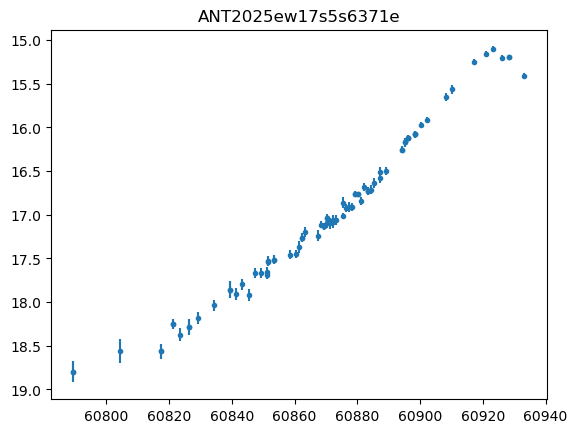

In [12]:
plot_lightcurve(dk_locus, include_microlensing = False)

## Current microlensing candidates 4-28-26

In [94]:
query = {
    "query": {
        "bool": {
            "filter": [
                {
                    "term": {
                        "tags": "microlensing_candidate"
                    }
                }
            ]
        }
    }
}

locus_ids = []

for locus in search.search(query):
    locus_ids.append(locus.locus_id)

In [96]:
current_candidate = []
loci = []
for locus_id in locus_ids:
    locus = search.get_by_id(locus_id)
    dk_locus = DevKitLocus.model_validate(locus.to_devkit())
    microlens_filter = antares_microlensing_filter.microlensing()
    report = microlens_filter.run(locus=dk_locus)
    if 'microlensing_candidate_test' in dk_locus.tags:
        current_candidate.append(locus_id)
        loci.append(dk_locus)

Processing Locus: ANT2018ctxf2
Processing Locus: ANT2022sjdol5w7vrl1
R
g
Processing Locus: ANT2019ui4mi
R
g
i


/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Processing Locus: ANT2021f5dh2


/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Processing Locus: ANT2020cilgs
Processing Locus: ANT20268wu13k0yijx8
R
g
i
Processing Locus: ANT2021lnnlg
R
g
i


...

Processing Locus: ANT20262kxdqmh463rl
Processing Locus: ANT2021ousau
R
i
Locus ANT2021ousau is a microlensing candidate in band i


/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Processing Locus: ANT20260ctmtzowdipj
R
Locus ANT20260ctmtzowdipj is a microlensing candidate in band R
g
Locus ANT20260ctmtzowdipj is a microlensing candidate in band g
i
Locus ANT20260ctmtzowdipj is a microlensing candidate in band i
Processing Locus: ANT2021gxxia
R
g
i
Processing Locus: ANT2026vz59b3zbihrq
R
g
i
Processing Locus: ANT2021gpibq
g
i
Processing Locus: ANT202640amm8ysh27v
Processing Locus: ANT2018fdvce
Processing Locus: ANT2021rjaio
Processing Locus: ANT2020jercs
R
i
Locus ANT2020jercs is a microlensing candidate in band i


/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Processing Locus: ANT2026awgkn7q94r5u
R
Locus ANT2026awgkn7q94r5u is a microlensing candidate in band R
g
Locus ANT2026awgkn7q94r5u is a microlensing candidate in band g
Processing Locus: ANT2026hc4g0p60k3pl
R
g
i
Processing Locus: ANT20265pq2i283eufs
R
g
i
Processing Locus: ANT2026ekrdf6ho31o4
R
Locus ANT2026ekrdf6ho31o4 is a microlensing candidate in band R
g
i
Processing Locus: ANT2026fnxd8t9540bo
R
g
Locus ANT2026fnxd8t9540bo is a microlensing candidate in band g
i
Locus ANT2026fnxd8t9540bo is a microlensing candidate in band i


In [99]:
len(loci)

0

In [97]:
# Find objects that have been identified in more that one filter as microlensing
for locus in loci:
    if len(locus.properties['microlensing_candidate_band'].split(',')) > 1:
        print(locus.id)

In [98]:
for locus in loci:
    print(locus.id)
    plot_lightcurve(locus, include_microlensing = False)


## Random alerts

In [22]:

from antares_devkit.utils import filter_report
import time

Processing Locus: ANT2019ffsx4
Too skewed
Failed von Neumann threshold
0.10298705101013184


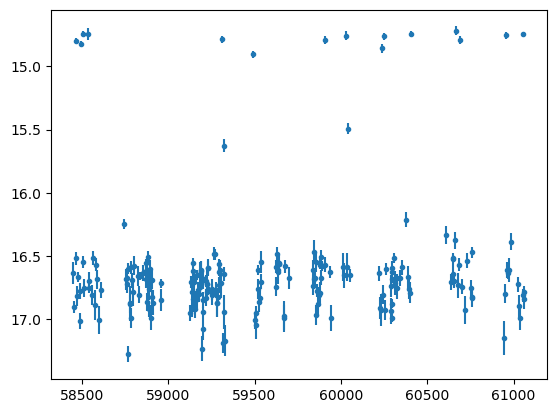

Processing Locus: ANT2020jqewc
Other known phenomenon
Other known phenomenon
0.09019589424133301


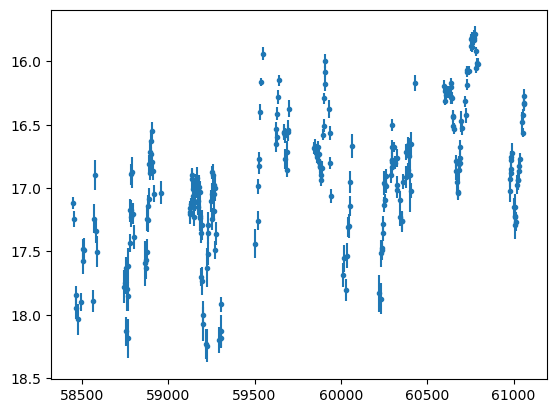

2.288818359375e-05


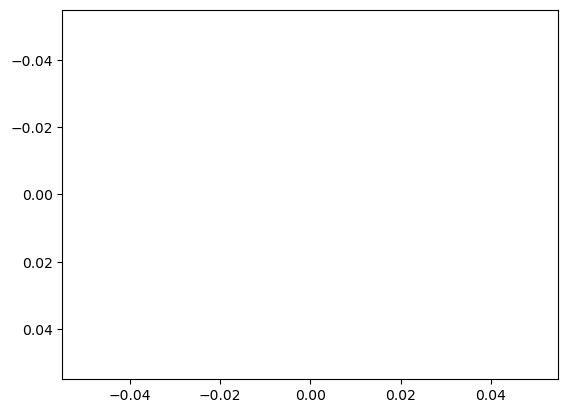

Processing Locus: ANT2025yn4m57ofaahp
Too Few Datapoints
Too Few Datapoints
0.08346176147460938


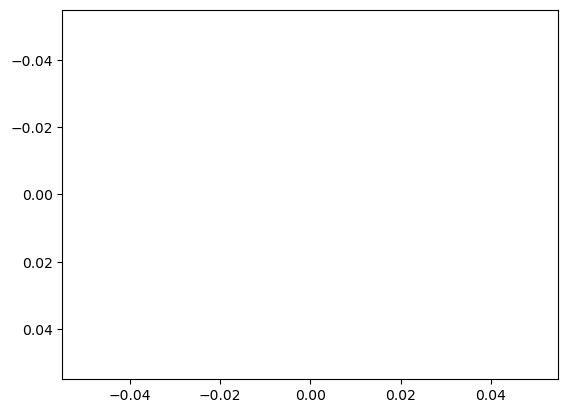

1.811981201171875e-05


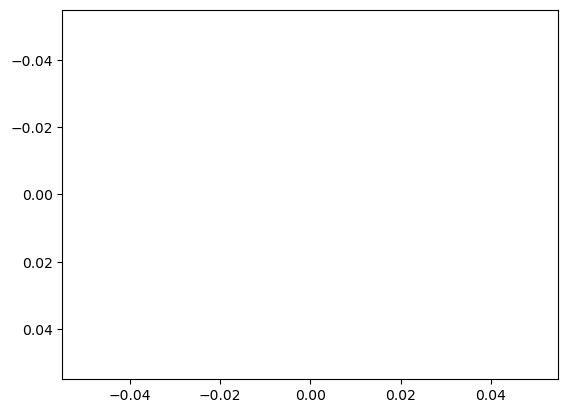

2.8133392333984375e-05


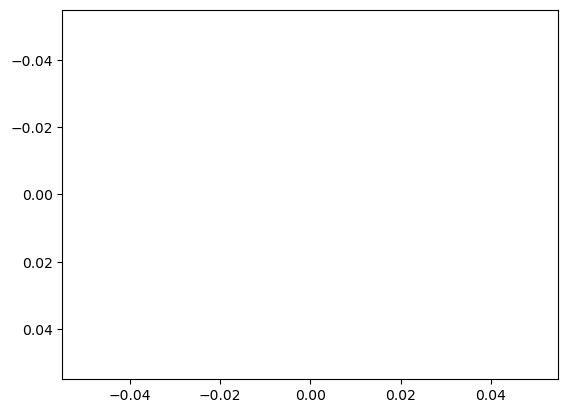

Processing Locus: ANT2020riqta
Other known phenomenon
Other known phenomenon
0.0949409008026123


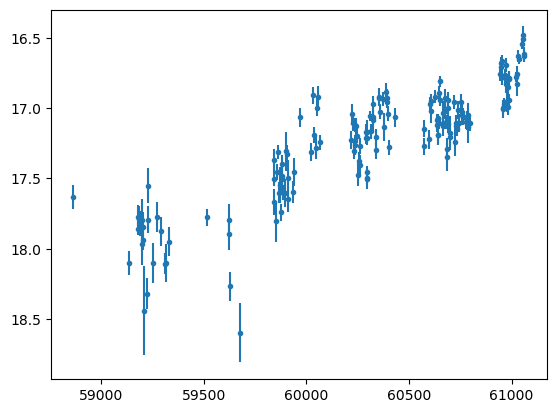

Processing Locus: ANT2020maj3g
Failed von Neumann threshold
Too skewed
0.08711791038513184


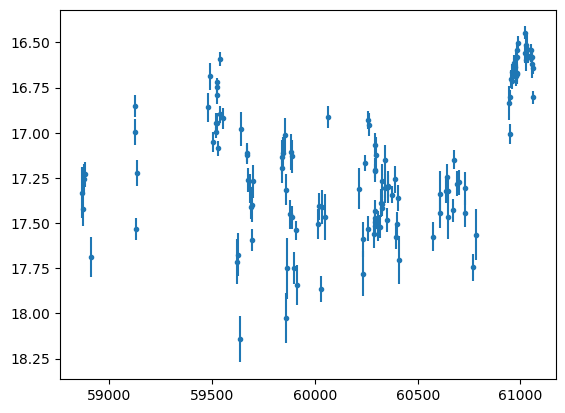

3.504753112792969e-05


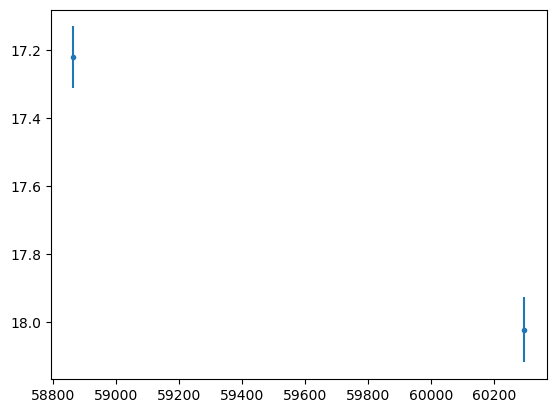

1.71661376953125e-05


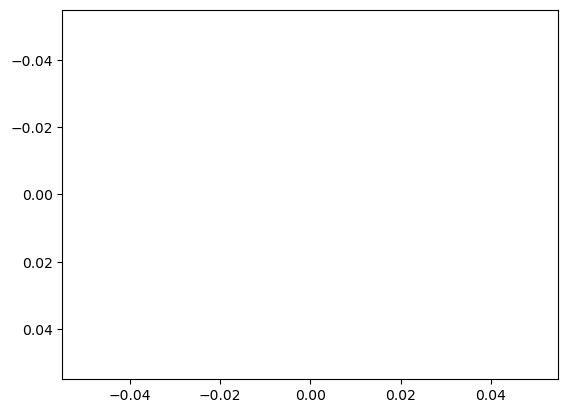

Processing Locus: ANT2020lfmdm
Other known phenomenon
Other known phenomenon
0.10610413551330566


/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


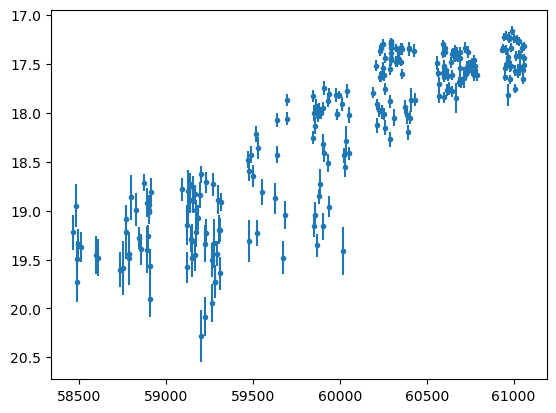

Processing Locus: ANT2020jqexe
Other known phenomenon
Other known phenomenon
0.09295892715454102


/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


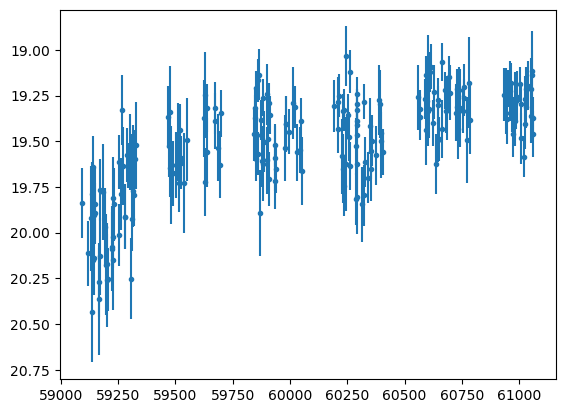

3.695487976074219e-05


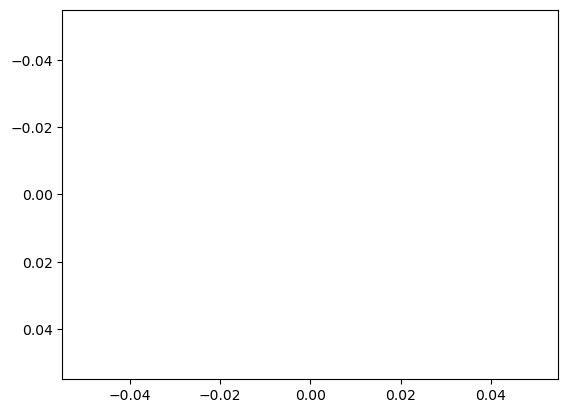

Processing Locus: ANT2020jqdnc
Failed von Neumann threshold
Failed von Neumann threshold
0.13023996353149414


/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


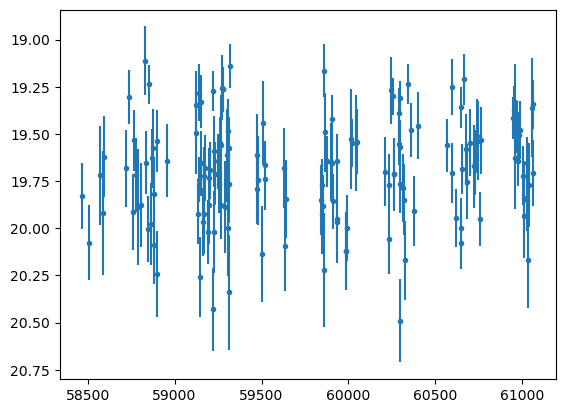

1.0013580322265625e-05


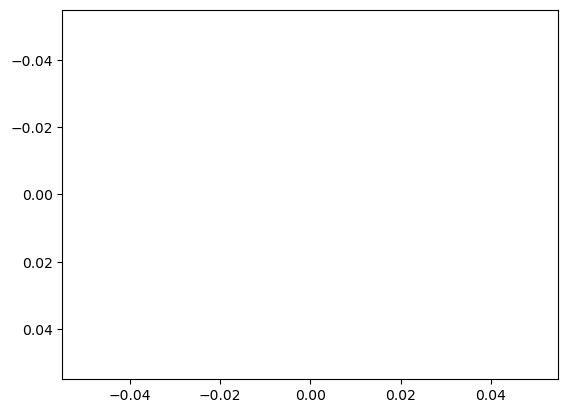

Processing Locus: ANT2020jqgmi
Other known phenomenon
Other known phenomenon
0.10124707221984863


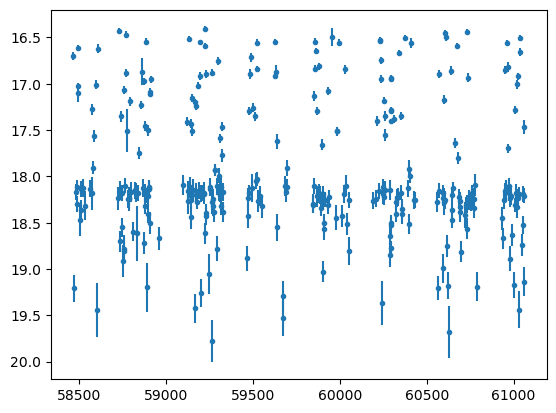

Processing Locus: ANT2020ikmee
Failed von Neumann threshold
Failed von Neumann threshold
0.10477113723754883


/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


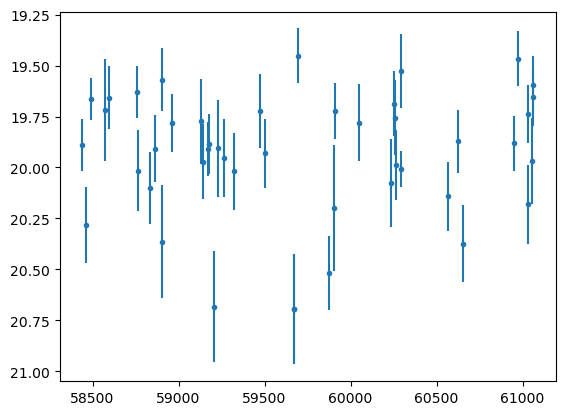

2.5987625122070312e-05


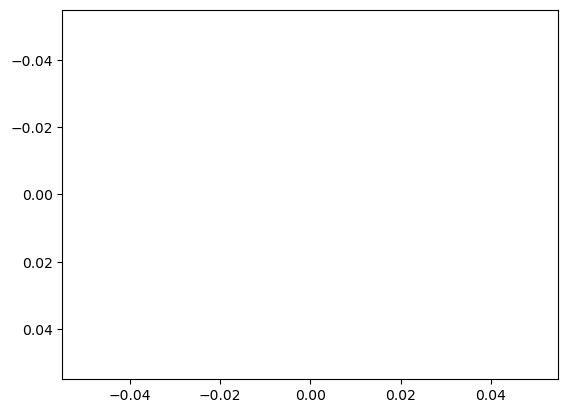

2.288818359375e-05


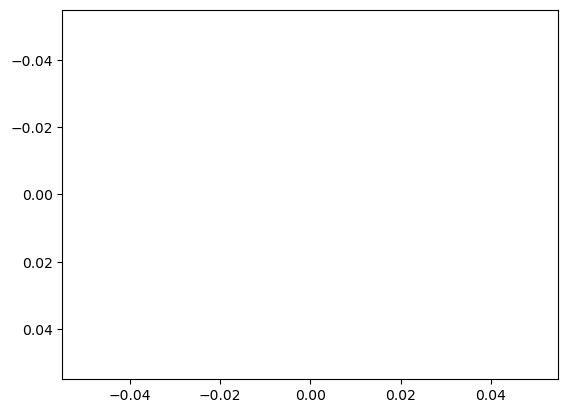

Processing Locus: ANT2020iqina
Other known phenomenon
Other known phenomenon
0.11205315589904785


/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


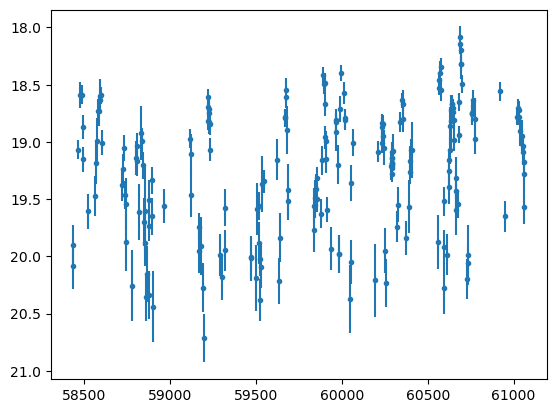

1.2159347534179688e-05


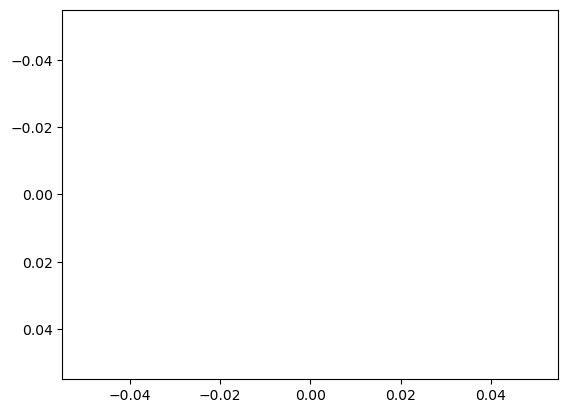

Processing Locus: ANT2020lg3pi
Other known phenomenon
Other known phenomenon
0.10543704032897949


/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


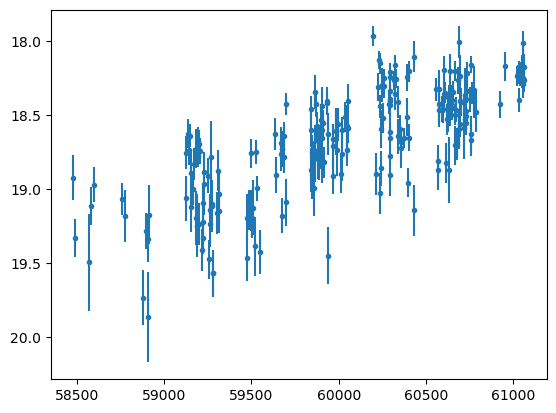

2.002716064453125e-05


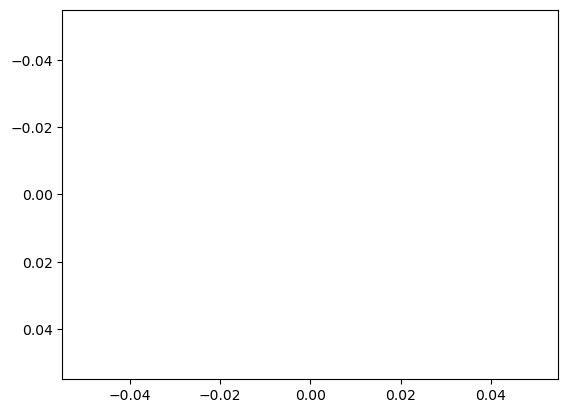

1.6927719116210938e-05


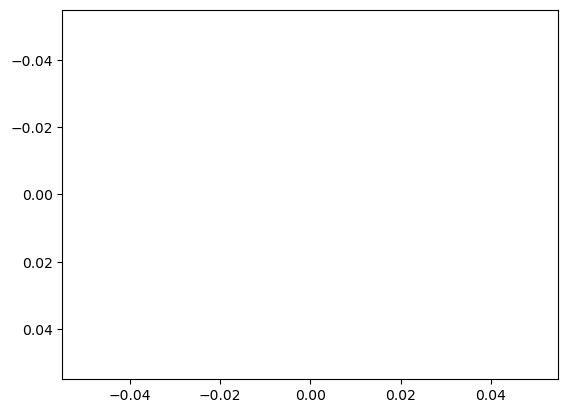

Processing Locus: ANT2020ikj3m
Other known phenomenon
Other known phenomenon
0.12064194679260254


/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


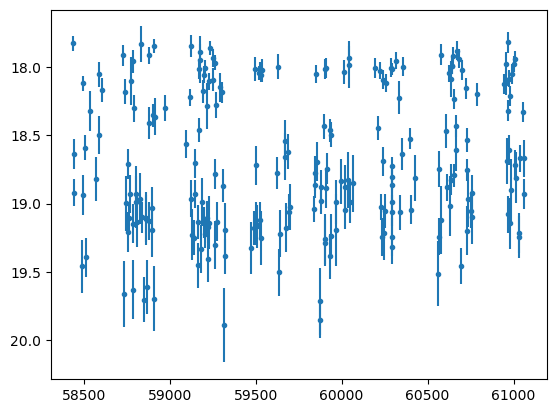

Processing Locus: ANT2019fend2
Other known phenomenon
Other known phenomenon
0.10568881034851074


/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


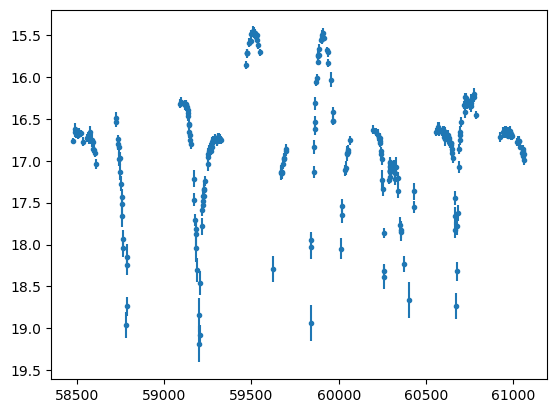

1.9311904907226562e-05


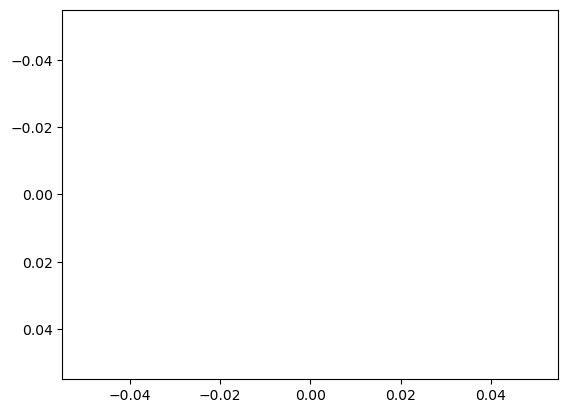

1.4066696166992188e-05


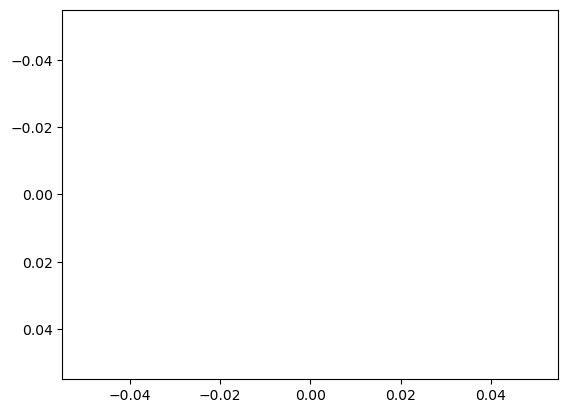

Processing Locus: ANT2020sjlum
Other known phenomenon
Other known phenomenon
0.09924602508544922


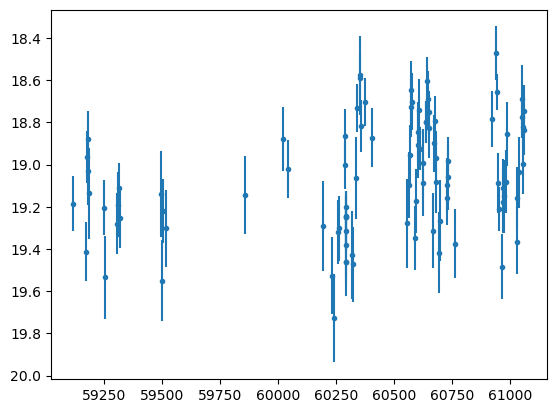

1.0967254638671875e-05


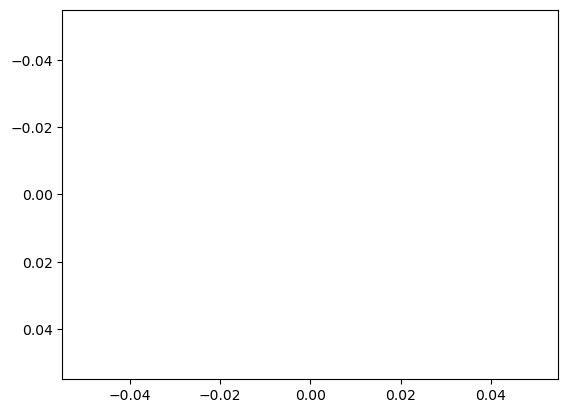

1.0013580322265625e-05


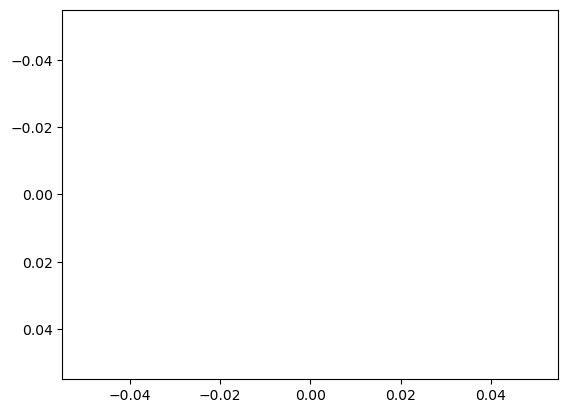

7.867813110351562e-06


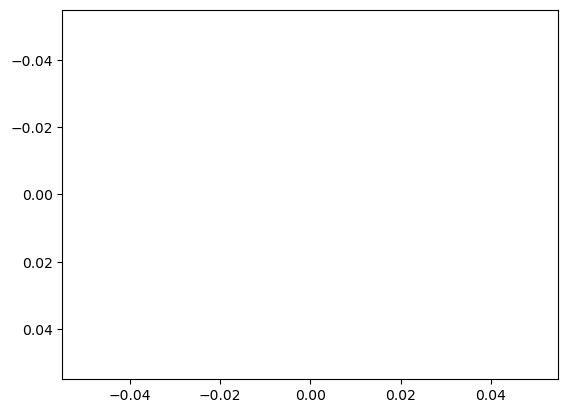

1.5974044799804688e-05


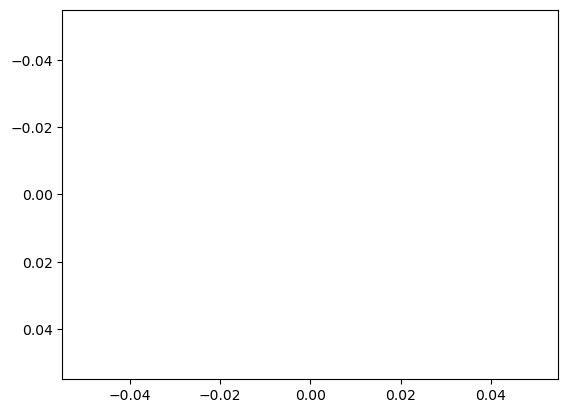

1.52587890625e-05


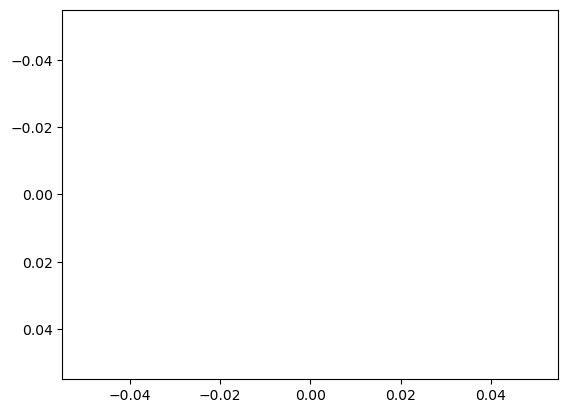

Processing Locus: ANT2020eeona
Failed von Neumann threshold
Failed von Neumann threshold
0.15700101852416992


/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


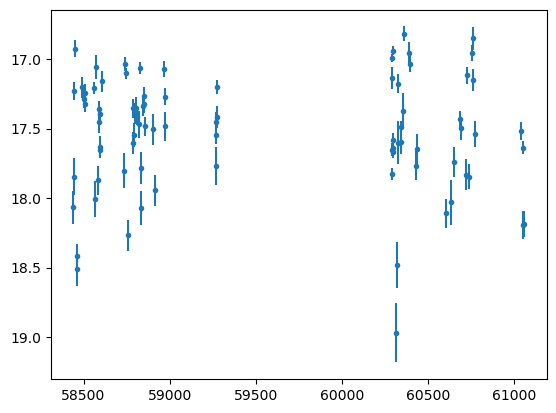

2.002716064453125e-05


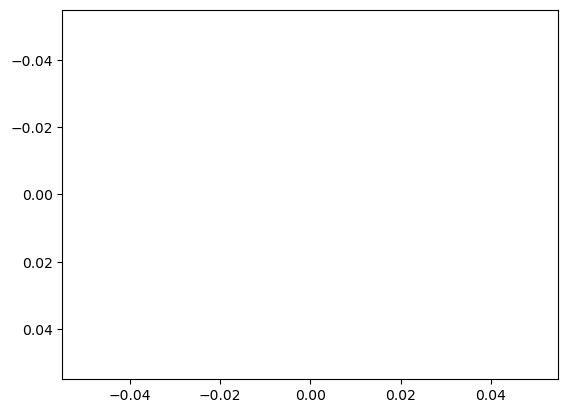

2.6941299438476562e-05


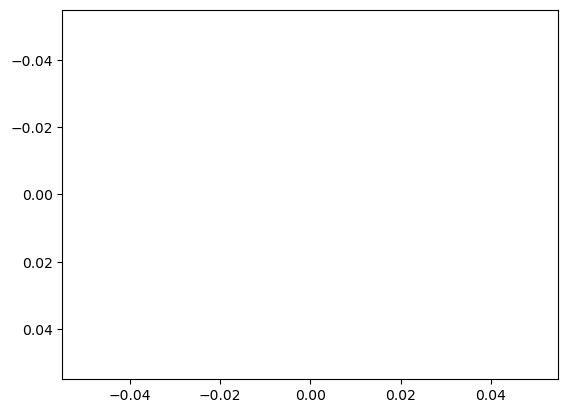

Processing Locus: ANT2020eel7k
Other known phenomenon
Other known phenomenon
0.09267473220825195


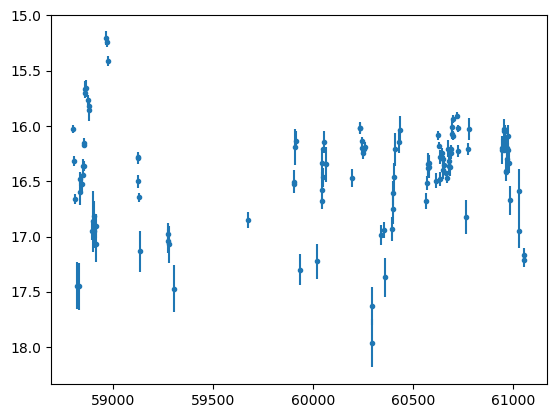

Processing Locus: ANT2020l6ksc
Other known phenomenon
Other known phenomenon
0.1161651611328125


/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


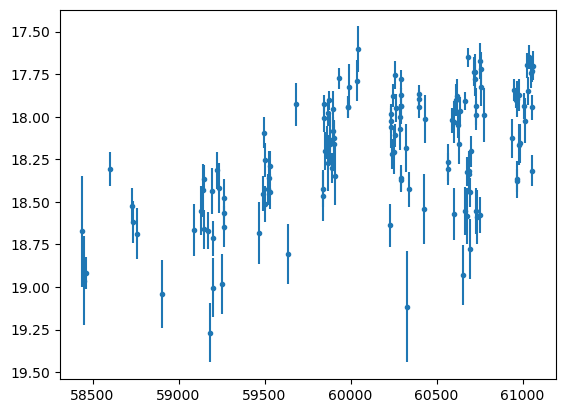

5.793571472167969e-05


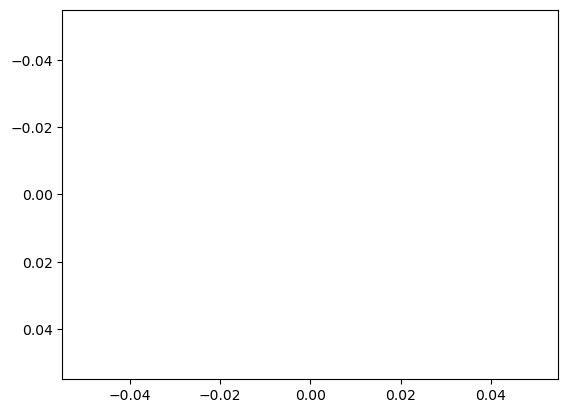

Processing Locus: ANT2020ed2fy
Other known phenomenon
Other known phenomenon
0.11515522003173828


/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


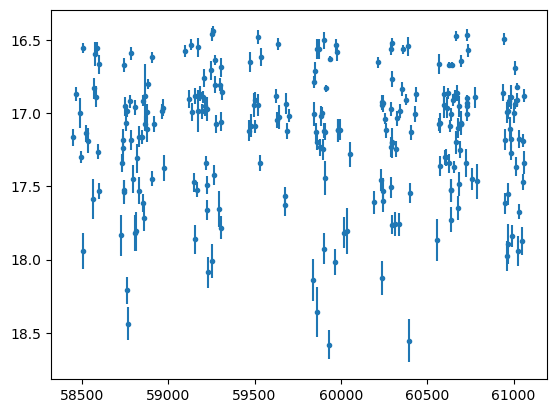

2.09808349609375e-05


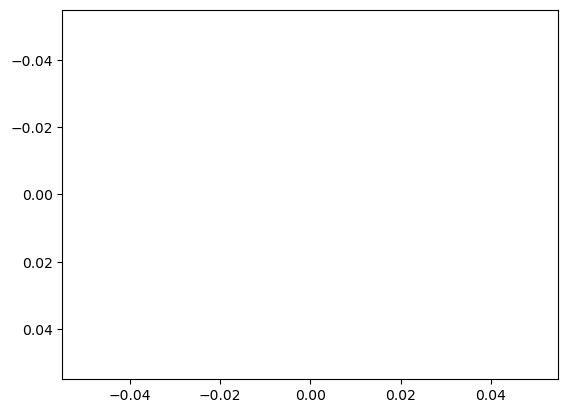

2.1219253540039062e-05


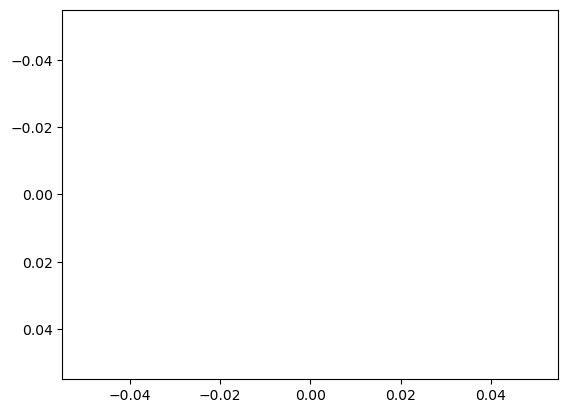

1.4066696166992188e-05


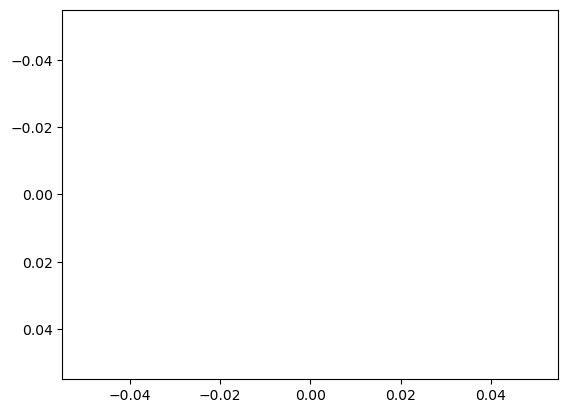

1.5735626220703125e-05


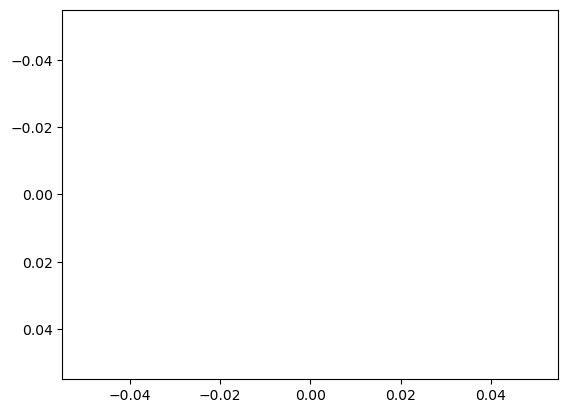

Processing Locus: ANT2020lx23i
Failed von Neumann threshold
Failed von Neumann threshold
0.20512819290161133


/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


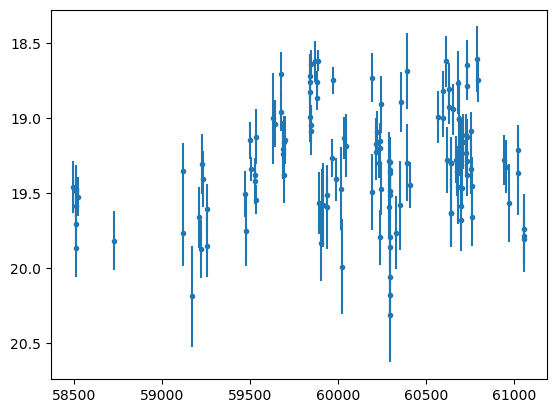

2.7894973754882812e-05


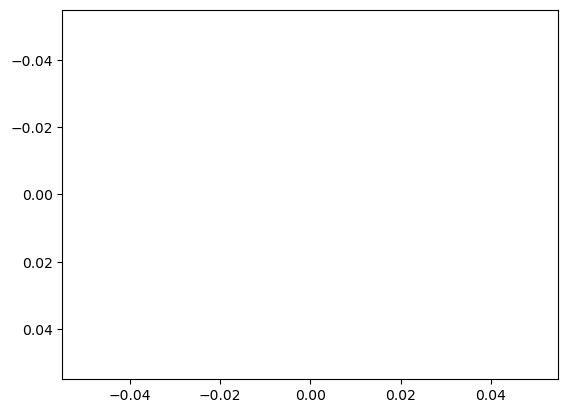

7.867813110351562e-06


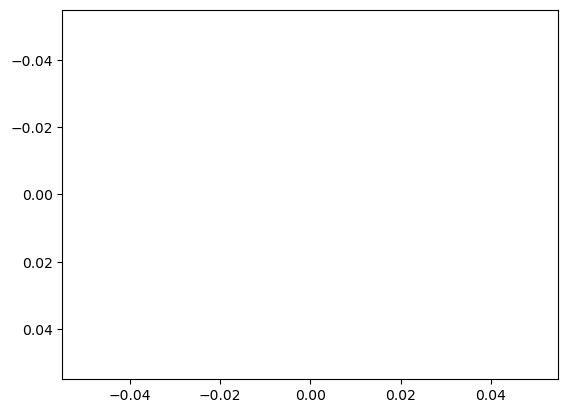

Processing Locus: ANT2020i6r2e
Failed von Neumann threshold
Failed von Neumann threshold
0.11911296844482422


/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


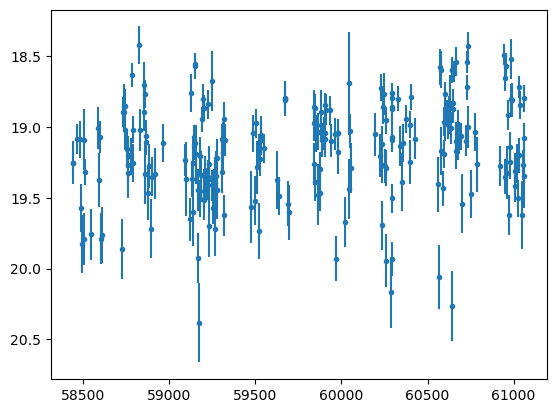

4.7206878662109375e-05


/opt/mambaforge3/envs/antares/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


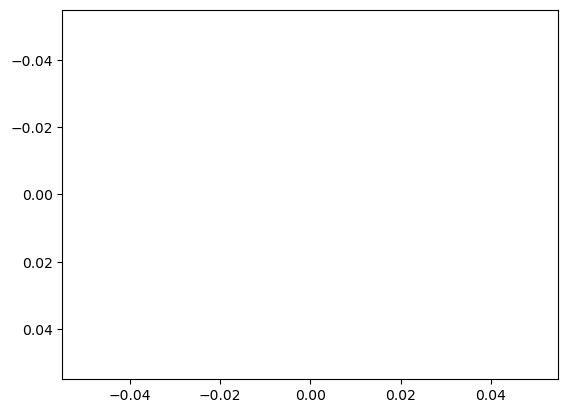

In [76]:
random_ids = search.get_random_locus_ids(n=50)
ts = np.zeros(50)
for i, random_id in enumerate(random_ids):
    locus = search.get_by_id(random_id)
    dk_locus = DevKitLocus.model_validate(locus.to_devkit())
    t0 = time.time()
    report = microlens_filter.run(locus=dk_locus)
    t_tot = time.time() - t0
    print(t_tot)
    ts[i] = t_tot
    plot_lightcurve(dk_locus)
    plt.close('all')

In [78]:
np.mean(ts)

0.04685897350311279